In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm.notebook import tqdm


SEED = 1337
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
def make_moons(n_samples=100, noise=0.2, random_state=None):
    """
    Simple reimplementation of sklearn.datasets.make_moons
    Returns X (n,2) and y (n,)
    """
    rng = np.random.RandomState(random_state)
    n_out = n_samples // 2
    n_in = n_samples - n_out

    # Outer (first) moon
    t1 = rng.rand(n_in) * np.pi
    x1 = np.stack([np.cos(t1), np.sin(t1)], axis=1)

    # Inner (second) moon
    t2 = rng.rand(n_out) * np.pi
    x2 = np.stack([1 - np.cos(t2), -np.sin(t2) + 0.5], axis=1)

    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n_in, dtype=int), np.ones(n_out, dtype=int)])

    # add noise
    X += rng.normal(scale=noise, size=X.shape)

    # shuffle
    perm = rng.permutation(n_samples)
    return X[perm], y[perm]


x, y = make_moons(n_samples=100, noise=0.2, random_state=SEED)
print(x.shape, y.sum())

(100, 2) 50


In [ ]:
# train + test (each 500)
X_train_raw, y_train_raw = make_moons(500, noise=0.2, random_state=SEED)
X_test_default, y_test_default = make_moons(500, noise=0.2, random_state=SEED+1)
X_test_low, y_test_low = make_moons(500, noise=0.1, random_state=SEED+2)
X_test_high, y_test_high = make_moons(500, noise=0.3, random_state=SEED+3)

print("Train shape:", X_train_raw.shape, y_train_raw.sum(), " pos")
print("Test shape:", X_test_default.shape, "pos ", y_test_default.sum())


Train shape: (500, 2) 250  pos
Test shape: (500, 2) pos  250


In [ ]:

X_train_full = X_train_raw.copy()
y_train_full = y_train_raw.copy()

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full)

# standardization
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0, ddof=0)
train_std[train_std == 0] = 1.0

def standardize(X, mean=train_mean, std=train_std):
    return (X - mean) / std

X_train_s = standardize(X_train)
X_val_s = standardize(X_val)
X_test_default_s = standardize(X_test_default)
X_test_low_s = standardize(X_test_low)
X_test_high_s = standardize(X_test_high)

print("Standardized shapes:", X_train_s.shape, X_val_s.shape)


Standardized shapes: (400, 2) (100, 2)


In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x.squeeze(-1)

def param_count(model):
    return sum(p.numel() for p in model.parameters())

def layerwise_sparsity(model, eps=1e-3):
    stats = {}
    for name, p in model.named_parameters():
        if p.requires_grad and p.dim()>0:
            w = p.detach().cpu().numpy().ravel()
            stats[name] = float((np.abs(w) < eps).sum()) / w.size
    return stats

def train_model_torch(model, X_tr, y_tr, X_val, y_val,
                      n_epochs=2000, lr=1e-3, patience=50,
                      l1_lambda=0.0, weight_decay=0.0, verbose=False):
    model = deepcopy(model)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    bce = nn.BCEWithLogitsLoss()
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)

    best_state = deepcopy(model.state_dict())
    best_metric = -np.inf
    wait = 0

    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        logits = model(X_tr_t)
        loss = bce(logits, y_tr_t)
        if l1_lambda > 0:
            l1 = 0.0
            for p in model.parameters():
                l1 = l1 + torch.sum(torch.abs(p))
            loss = loss + l1_lambda * l1
        loss.backward()
        opt.step()

        # validation metric
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t).cpu().numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))
            try:
                val_auc = roc_auc_score(y_val, val_probs)
            except:
                val_auc = 0.5
        if val_auc > best_metric + 1e-8:
            best_metric = val_auc
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
        if verbose and (epoch % 200 == 0):
            print(f"Epoch {epoch}, loss {loss.item():.4f}, val_auc {val_auc:.4f}")
        if wait >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_metric


In [ ]:
# MLP baseline with early stopping (patience=50)
base_model = SimpleMLP(input_dim=2, hidden_dim=32)
print("Params baseline:", param_count(base_model))
model1, val_auc1 = train_model_torch(
    base_model, X_train_s, y_train, X_val_s, y_val,
    n_epochs=2000, lr=1e-3, patience=50, l1_lambda=0.0, weight_decay=0.0, verbose=True
)
print("Model1 val AUROC:", val_auc1)


Params baseline: 129
Epoch 0, loss 0.6350, val_auc 0.9564
Model1 val AUROC: 0.9580000000000001


In [ ]:
# Train MLP with L1 regularization grid and report sparsity & val AUROC and selecet best
l1_grid = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
l1_results = []
for lam in l1_grid:
    m = SimpleMLP(input_dim=2, hidden_dim=32)
    trained, val_auc = train_model_torch(m, X_train_s, y_train, X_val_s, y_val,
                                         n_epochs=2000, lr=1e-3, patience=50,
                                         l1_lambda=lam, weight_decay=0.0, verbose=False)
    spars = layerwise_sparsity(trained, eps=1e-3)
    l1_results.append({"lambda": lam, "val_auc": val_auc, "sparsity": spars, "model": trained})
    print(f"L1 {lam:.0e} -> val AUROC {val_auc:.4f}, sparsity (percent zeros) ->",
          {k: f"{v*100:.1f}%" for k,v in spars.items()})

best_l1 = max(l1_results, key=lambda r: r["val_auc"])
print("Best L1 lambda:", best_l1["lambda"], "val AUROC:", best_l1["val_auc"])
model2 = best_l1["model"]


L1 1e-06 -> val AUROC 0.9692, sparsity (percent zeros) -> {'fc1.weight': '0.0%', 'fc1.bias': '0.0%', 'fc2.weight': '0.0%', 'fc2.bias': '0.0%'}
L1 3e-06 -> val AUROC 0.9760, sparsity (percent zeros) -> {'fc1.weight': '0.0%', 'fc1.bias': '0.0%', 'fc2.weight': '3.1%', 'fc2.bias': '0.0%'}
L1 1e-05 -> val AUROC 0.9904, sparsity (percent zeros) -> {'fc1.weight': '3.1%', 'fc1.bias': '3.1%', 'fc2.weight': '3.1%', 'fc2.bias': '0.0%'}
L1 3e-05 -> val AUROC 0.9708, sparsity (percent zeros) -> {'fc1.weight': '0.0%', 'fc1.bias': '0.0%', 'fc2.weight': '3.1%', 'fc2.bias': '0.0%'}
L1 1e-04 -> val AUROC 0.9972, sparsity (percent zeros) -> {'fc1.weight': '0.0%', 'fc1.bias': '0.0%', 'fc2.weight': '6.2%', 'fc2.bias': '0.0%'}
L1 3e-04 -> val AUROC 0.9656, sparsity (percent zeros) -> {'fc1.weight': '0.0%', 'fc1.bias': '0.0%', 'fc2.weight': '3.1%', 'fc2.bias': '0.0%'}
Best L1 lambda: 0.0001 val AUROC: 0.9972000000000001


In [ ]:
# Train MLP with L2 (weight decay) - tune weight_decay by validation AUROC
l2_grid = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
l2_results = []
for wd in l2_grid:
    m = SimpleMLP(input_dim=2, hidden_dim=32)
    trained, val_auc = train_model_torch(m, X_train_s, y_train, X_val_s, y_val,
                                         n_epochs=2000, lr=1e-3, patience=50,
                                         l1_lambda=0.0, weight_decay=wd, verbose=False)
    spars = layerwise_sparsity(trained)
    l2_results.append({"wd": wd, "val_auc": val_auc, "sparsity": spars, "model": trained})
    print(f"L2 wd={wd:.0e}: val AUROC {val_auc:.4f}")

best_l2 = max(l2_results, key=lambda r: r["val_auc"])
print("Best L2 weight_decay:", best_l2["wd"], "val AUROC:", best_l2["val_auc"])
model3 = best_l2["model"]


L2 wd=1e-06: val AUROC 0.9784
L2 wd=1e-05: val AUROC 0.9872
L2 wd=1e-04: val AUROC 0.9676
L2 wd=1e-03: val AUROC 0.9972
L2 wd=1e-02: val AUROC 0.9604
Best L2 weight_decay: 0.001 val AUROC: 0.9972000000000001


In [ ]:
# Cell 10 - Logistic regression with polynomial features (degree 2: x1,x2,x1^2,x2^2,x1x2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_s)
X_val_poly = poly.transform(X_val_s)
X_test_default_poly = poly.transform(X_test_default_s)
lr = LogisticRegression(max_iter=2000, solver='lbfgs')
lr.fit(X_train_poly, y_train)
print("Logistic val AUROC:", roc_auc_score(y_val, lr.predict_proba(X_val_poly)[:,1]))
model4 = lr


Logistic val AUROC: 0.9663999999999999


In [ ]:
# Evaluation function for models on any dataset
def eval_torch_model(model, X, y):
    model.eval()
    Xt = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        logits = model(Xt).cpu().numpy()
        probs = 1 / (1 + np.exp(-logits))
        preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(y, preds)
    auc = roc_auc_score(y, probs)
    return acc, auc, probs

def eval_sklearn_model(model, X, y):
    probs = model.predict_proba(X)[:,1]
    preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(y, preds)
    auc = roc_auc_score(y, probs)
    return acc, auc, probs

In [ ]:
# Cell 12 - Evaluate all models on the three test noise levels and create a table
models_info = [
    {"name": "MLP_baseline", "type": "torch", "model": model1, "params": param_count(model1)},
    {"name": "MLP_L1_best", "type": "torch", "model": model2, "params": param_count(model2)},
    {"name": "MLP_L2_best", "type": "torch", "model": model3, "params": param_count(model3)},
    {"name": "Logistic_poly", "type": "sklearn", "model": model4, "params": lr.coef_.size + lr.intercept_.size}
]

testsets = [
    ("noise_0.2", X_test_default_s, y_test_default),
    ("noise_0.1", X_test_low_s, y_test_low),
    ("noise_0.3", X_test_high_s, y_test_high)
]

results_table = []
for minfo in models_info:
    row = {"model": minfo["name"], "params": minfo["params"]}
    for tname, Xts, yts in testsets:
        if minfo["type"] == "torch":
            acc, auc, _ = eval_torch_model(minfo["model"], Xts, yts)
        else:
            acc, auc, _ = eval_sklearn_model(minfo["model"], Xts if 'poly' not in minfo['name'] else poly.transform(Xts), yts)
        row[f"{tname}_acc"] = acc
        row[f"{tname}_auc"] = auc
    results_table.append(row)

# Print table
import pandas as pd
df_results = pd.DataFrame(results_table)
pd.set_option('display.float_format', lambda x: f"{x:.4f}")
df_results


,model,params,noise_0.2_acc,noise_0.2_auc,noise_0.1_acc,noise_0.1_auc,noise_0.3_acc,noise_0.3_auc
0,MLP_baseline,129,0.8260,0.9310,0.8600,0.9516,0.7860,0.9315
1,MLP_L1_best,129,0.9440,0.9878,0.9820,0.9989,0.9020,0.9772
2,MLP_L2_best,129,0.9380,0.9870,0.9840,0.9989,0.9000,0.9766
3,Logistic_poly,6,0.8700,0.9472,0.8940,0.9696,0.8560,0.9449


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


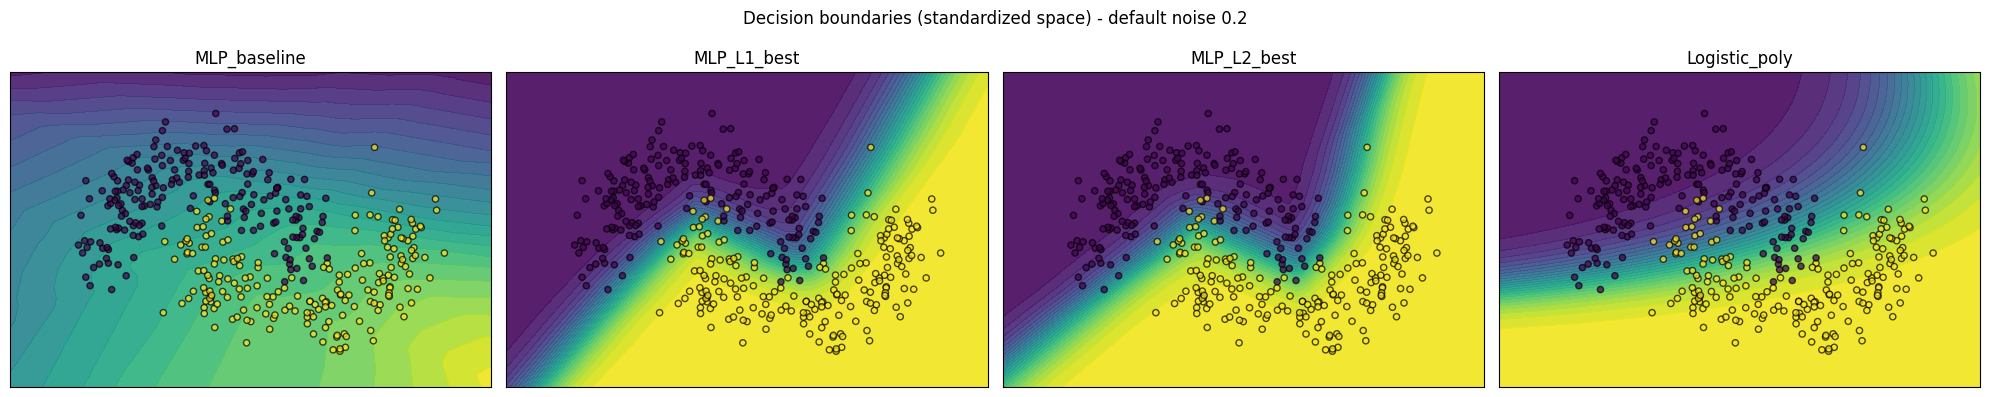

In [ ]:
# Cell 13 - Plot decision boundaries side-by-side for the 4 models (noise=0.2)
def plot_decision(ax, model_info, Xref, poly_transform=None, title=""):
    # create mesh on standardized feature ranges
    x_min, x_max = Xref[:,0].min()-0.5, Xref[:,0].max()+0.5
    y_min, y_max = Xref[:,1].min()-0.5, Xref[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if model_info['type'] == "torch":
        _, _, probs = eval_torch_model(model_info['model'], grid, np.zeros(len(grid), dtype=int))
        Z = probs.reshape(xx.shape)
    else:
        Xg = poly_transform(grid) if poly_transform is not None else grid
        probs = model_info['model'].predict_proba(Xg)[:,1]
        Z = probs.reshape(xx.shape)
    cs = ax.contourf(xx, yy, Z, levels=25, alpha=0.9)
    # plot train points (original standardized train)
    ax.scatter(X_train_s[:,0], X_train_s[:,1], c=y_train, edgecolor='k', s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1,4, figsize=(20,4))
for ax, minfo in zip(axes, models_info):
    plot_decision(ax, minfo, np.vstack([X_train_s, X_val_s, X_test_default_s]),
                  poly_transform=(poly.transform if minfo['name']=="Logistic_poly" else None),
                  title=f"{minfo['name']}")
plt.suptitle("Decision boundaries (standardized space) - default noise 0.2")
plt.tight_layout()
plt.show()


observations:

L1 regularisation
- Sparsity: L1 regularisation adds a penalty proportional to the absolute value of weights. This sets many parameters to exactly zero, resulting in a sparse matrix.
- Effect on Boundary:
Because L1 sets many parameters to exactly zero, the model uses fewer active connections to make predictions. This causes linear decision boundaries — sharper, sometimes jagged edges where the decision function changes.

L2 regularisation
- Smoothness:
L2 regularisation penalises the square of weights, which keeps all weights small., This yields smoother transitions in the decision surface since no single neuron dominates.
- Margin effect:
Smaller weights correspond to larger margins, that is, the distance between classes. This results in more robust generalisation as the model’s predictions change less under small input perturbations.


In [ ]:
#Create imbalanced training set (70:30)
def make_imbalanced_train(n_samples=500, noise=0.2, ratio_pos=0.3, random_state=None):
    rng = np.random.RandomState(random_state)
    Xpool, ypool = make_moons(n_samples*4, noise=noise, random_state=random_state)

    X0 = Xpool[ypool==0]
    X1 = Xpool[ypool==1]
    n_pos = int(n_samples * ratio_pos)
    n_neg = n_samples - n_pos
    # if not enough samples, repeat sampling with replacement
    if len(X1) < n_pos:
        idx1 = rng.choice(len(X1), n_pos, replace=True)
    else:
        idx1 = rng.choice(len(X1), n_pos, replace=False)
    if len(X0) < n_neg:
        idx0 = rng.choice(len(X0), n_neg, replace=True)
    else:
        idx0 = rng.choice(len(X0), n_neg, replace=False)
    Ximb = np.vstack([X0[idx0], X1[idx1]])
    yimb = np.hstack([np.zeros(len(idx0), dtype=int), np.ones(len(idx1), dtype=int)])
    perm = rng.permutation(n_samples)
    return Ximb[perm], yimb[perm]

X_train_imb_raw, y_train_imb_raw = make_imbalanced_train(500, noise=0.2, ratio_pos=0.3, random_state=SEED+10)

# standardize s
imb_mean = X_train_imb_raw.mean(axis=0)
imb_std = X_train_imb_raw.std(axis=0)
imb_std[imb_std==0]=1.0
X_train_imb_s = (X_train_imb_raw - imb_mean) / imb_std

# validation splitt
X_tr_imb, X_val_imb, y_tr_imb, y_val_imb = train_test_split(
    X_train_imb_s, y_train_imb_raw, test_size=0.2, random_state=SEED, stratify=y_train_imb_raw
)

print("Imbalanced train counts:", np.bincount(y_tr_imb))


Imbalanced train counts: [280 120]


In [ ]:
# Retrain all 4 models on imbalanced train and evaluate on balanced tests
# MLP baseline retrain
m1_imb, _ = train_model_torch(SimpleMLP(), X_tr_imb, y_tr_imb, X_val_imb, y_val_imb,
                              n_epochs=2000, lr=1e-3, patience=50, l1_lambda=0.0, weight_decay=0.0)
# MLP L1 with best lambda from earlier
best_l1_lambda = best_l1['lambda']
m2_imb, _ = train_model_torch(SimpleMLP(), X_tr_imb, y_tr_imb, X_val_imb, y_val_imb,
                              n_epochs=2000, lr=1e-3, patience=50, l1_lambda=best_l1_lambda, weight_decay=0.0)
# MLP L2 with best wd from earlier
best_l2_wd = best_l2['wd']
m3_imb, _ = train_model_torch(SimpleMLP(), X_tr_imb, y_tr_imb, X_val_imb, y_val_imb,
                              n_epochs=2000, lr=1e-3, patience=50, l1_lambda=0.0, weight_decay=best_l2_wd)
# Logistic poly retrain
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_tr_imb_poly = poly2.fit_transform(X_tr_imb)
X_val_imb_poly = poly2.transform(X_val_imb)
lr_imb = LogisticRegression(max_iter=2000, solver='lbfgs')
lr_imb.fit(X_tr_imb_poly, y_tr_imb)

# Evaluate
X_test_default_imb_s = (X_test_default - imb_mean) / imb_std
X_test_low_imb_s = (X_test_low - imb_mean) / imb_std
X_test_high_imb_s = (X_test_high - imb_mean) / imb_std

imb_models = [
    {"name": "MLP_baseline_imb", "type":"torch", "model": m1_imb, "params": param_count(m1_imb)},
    {"name": "MLP_L1_imb", "type":"torch", "model": m2_imb, "params": param_count(m2_imb)},
    {"name": "MLP_L2_imb", "type":"torch", "model": m3_imb, "params": param_count(m3_imb)},
    {"name": "Logistic_poly_imb", "type":"sklearn", "model": lr_imb, "params": lr_imb.coef_.size + lr_imb.intercept_.size}
]
testsets_imb = [("noise_0.2", X_test_default_imb_s, y_test_default),
                ("noise_0.1", X_test_low_imb_s, y_test_low),
                ("noise_0.3", X_test_high_imb_s, y_test_high)]

results_table_imb = []
for m in imb_models:
    row = {"model": m["name"], "params": m["params"]}
    for tname, Xts, yts in testsets_imb:
        if m["type"] == "torch":
            acc, auc, _ = eval_torch_model(m["model"], Xts, yts)
        else:
            Xg = poly2.transform(Xts)
            acc, auc, _ = eval_sklearn_model(m["model"], Xg, yts)
        row[f"{tname}_acc"] = acc
        row[f"{tname}_auc"] = auc
    results_table_imb.append(row)

pd.DataFrame(results_table_imb)


,model,params,noise_0.2_acc,noise_0.2_auc,noise_0.1_acc,noise_0.1_auc,noise_0.3_acc,noise_0.3_auc
0,MLP_baseline_imb,129,0.8320,0.9464,0.8640,0.9669,0.8480,0.9476
1,MLP_L1_imb,129,0.6240,0.9439,0.6100,0.9654,0.6540,0.9443
2,MLP_L2_imb,129,0.9260,0.9806,0.9620,0.9963,0.8960,0.9653
3,Logistic_poly_imb,6,0.8520,0.9475,0.8820,0.9716,0.8420,0.9404


Effect of Class Imbalance

- Observation from results:
Accuracy dropped (especially for L1), but AUROC remained high.
- Accuracy decreases: Because the model predicts the majority class more frequently, minority-class samples are often misclassified.
- AUROC remains high: AUROC measures the ranking quality of predictions, not the threshold. So, even if the model outputs low probabilities for the minority class, as long as it ranks them correctly, the AUROC remains good.
- RegularisationRegularisation:
L1-regularised models were more sensitive to imbalance many weights were set to zero, reducing the flexibility to model features of the minority class.\
L2-regularised models were more robust and retained balanced decision surfaces, leading to better generalisation.
